In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import yaml

In [93]:
"""
results are saved to results folder. Enter the path here
results_np is a numpy array with dimensions (num_matrix_sizes, num_candidates, num_selection, num_algorithms, num_metrics)
"""

results_dir= "../results/2024-11-19_12-55-23"
results_pkl = glob.glob(results_dir + "/*.npy")[0]
config_yaml = glob.glob(results_dir + "/*.yaml")[0]
# read the data and config
results_np = np.load(results_pkl, allow_pickle=True)
config = yaml.load(open(config_yaml), Loader=yaml.FullLoader)
print(config)

{'algos': ['greedy', 'scipy', 'scipy-lse', 'frank-wolfe'], 'k_values': [5], 'measurement_dim': 10, 'metrics': ['unr_score', 'k-max', 'break-ties', 'madow', 'exec_time', 'sub-opt-gap'], 'num_matrices_list': [10], 'num_poses_list': [10, 50, 100], 'pose_dim': 6}


In [94]:
num_msizes , num_cands, num_k, _, _ = results_np.shape
algos = config['algos']
metrics = config['metrics']
measurement_dim = config['measurement_dim']
pose_dim = config['pose_dim']
# k_values
k_values = config['k_values']
matrix_sizes = [measurement_dim + num_poses * pose_dim for num_poses in config['num_poses_list'] ]
# Define the list of num_matrices to test
num_matrices_list = config['num_matrices_list']

extracting results for matrix size :70, N::, K:5

####################  unrounded scores   ####################

         greedy      scipy  scipy-lse  frank-wolfe
N-10  35.004236  37.375945        0.0          0.0

####################  K-max scores  ####################

         greedy      scipy  scipy-lse  frank-wolfe
N-10  35.004236  34.803907        0.0          0.0

####################  Execution time   ####################

        greedy     scipy  scipy-lse  frank-wolfe
N-10  0.020547  2.320049        0.0          0.0


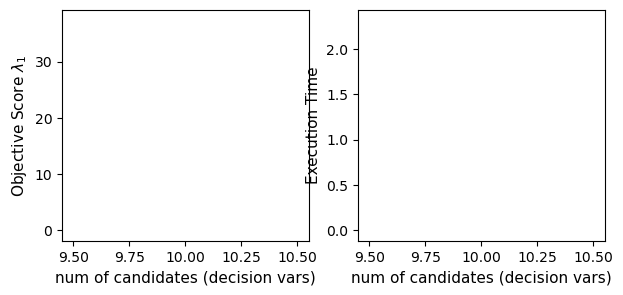

In [97]:
#Plot time taken for different algorithms
def pretty_print(title, x_labels, y_labels, data):
    # Suppress scientific notation and set the precision
    np.set_printoptions(suppress=True, precision=5)
    print("\n" + "#" * 20+"  "+title+"  "+"#" * 20+"\n")
    df = pd.DataFrame(data, columns=x_labels, index=y_labels)
    print(df)

def plot_results(xlabel_name, xlabels, unrounded_scores, rounded_scores, times, algos):
    """
    Visualizes the results of experimental evaluation. Plots scores and execution times
    :param xlabel_name: axis label to display on x-axis ( varying parameter)
    :param xlabels: list of x-axis labels of the parameter being analysed
    :param unrounded_scores: array of objective scores of the continous solution
    :param rounded_scores: array of objective score from the rounded solution (we want to expand this to different rounding results in future)
    :param times: array of execution times

    """
    colors=['r', 'g', 'b', 'm', 'y']
    plt.figure(figsize=(7, 3))
    plt.subplot(1, 2, 1) #comment here to plot singlefigure
    #plt.xticks([])
    for i, algo_name in enumerate(algos):
        plt.plot(xlabels, unrounded_scores[:,i] , label=algo_name,linewidth=2.0)
        plt.plot(xlabels, rounded_scores[:,i] ,c=colors[i], label="greedy",linewidth=2.0)
    plt.xlabel(xlabel_name, fontsize=11) #uncomment here to plot singlefigure
    plt.ylabel("Objective Score $\lambda_1$",fontsize=11)
    plt.subplot(1, 2, 2) #comment here to plot singlefigure
    #plt.xticks([])
    for i, algo_name in enumerate(algos):
        plt.plot(xlabels, times[:,i] ,c=colors[i], label=algo_name,linewidth=2.0)

    plt.xlabel(xlabel_name, fontsize=11)  #uncomment here to plot singlefigure
    plt.ylabel("Execution Time",fontsize=11)

#for N=300, plot for varying k
def extract_results(results_np, num_poses_ind, num_cands_ind, k_ind ):
    """
    indexes the results log and extracts the required 2D matrix of results
    :param results_np: results numpy array with dimensions (num_matrix_sizes, num_candidates, num_selection, num_algorithms, num_metrics)
    :param num_matrix_sizes: index or index range of number of poses dimension. Note number of poses corresponds to the matrix size.
    :param num_cands_ind: index or index range of number of candidates (num of matrices) dimension.
    :param k_ind: index or index range of number of sensors to select
    :return: Tuple (unrounded_scores, [rounded_scores], execution times)
    """
    unrounded_scores = results_np[num_poses_ind,num_cands_ind,k_ind,:,0]
    kmax_scores = results_np[num_poses_ind,num_cands_ind,k_ind,:,1]
    madow_scores = results_np[num_poses_ind,num_cands_ind,k_ind,:,3]
    times = results_np[num_poses_ind,num_cands_ind,k_ind,:,4]
    return unrounded_scores, kmax_scores, madow_scores, times

# extract the matrics for specific matrixsize, N and K and display
# eg : below we are extracting scores and times for matrix size = 70, k=2 for varying N
print("extracting results for matrix size :{}, N:{}, K:{}".format(matrix_sizes[0],":",k_values[0] ))
unrounded_scores, kmax_scores, madow_scores, times = extract_results(results_np, 0,slice(None, None, None), 0 )

#print the matrices
y_labels = ["N-{}".format(i) for i in num_matrices_list]
pretty_print("unrounded scores ",["greedy", "scipy", "scipy-lse", "frank-wolfe"],y_labels,unrounded_scores)
pretty_print( "K-max scores",["greedy", "scipy", "scipy-lse", "frank-wolfe"],y_labels,kmax_scores)
pretty_print( "Execution time ",["greedy", "scipy", "scipy-lse", "frank-wolfe"],y_labels, times)

#plot the scores and times
plot_results("num of candidates (decision vars)", num_matrices_list, unrounded_scores, kmax_scores, times, algos)

plt.show()